# Designing a Fashion Classifier for E-commerce

You are a part of an AI team at an e-commerce company that aims to automate clothing classification. Customers upload images of clothing to find similar items on the platform. Your task is to develop a robust image classification model that can correctly identify categories of clothing such as T-shirts, trousers, and shoes.

You have access to the Fashion-MNIST dataset, a collection of grayscale images of 10 fashion categories. The goal is to build a high-performing image classifier using transfer learning and optimize its performance for real-world applications.


In [39]:
# Import Required Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


Training data shape: (1000, 28, 28)
Test data shape: (100, 28, 28)


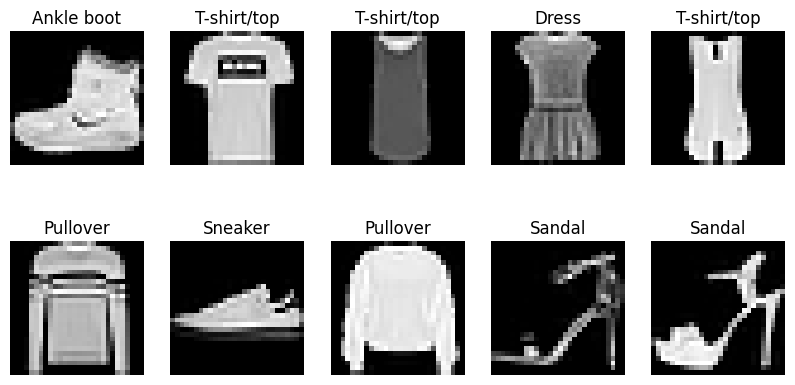

In [40]:
# Load Fashion-MNIST Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Use only a subset of the dataset for faster training
x_train = x_train[:1000]  # Use only 10,000 training samples
y_train = y_train[:1000]
x_test = x_test[:100]  # Use only 2,000 test samples
y_test = y_test[:100]

# Print Dataset Information
print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

# Visualize Sample Images
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [58]:
from collections import Counter

# Load the dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Summary statistics
print("=== Dataset Summary ===")
print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Image dimensions: {x_train.shape[1]}x{x_train.shape[2]}")

# Class distribution
train_class_distribution = Counter(y_train)
test_class_distribution = Counter(y_test)
print("\n=== Class Distribution (Training) ===")
for class_id, count in train_class_distribution.items():
    print(f"{class_names[class_id]}: {count} samples")

print("\n=== Class Distribution (Testing) ===")
for class_id, count in test_class_distribution.items():
    print(f"{class_names[class_id]}: {count} samples")

# Pixel intensity statistics
print("\n=== Pixel Intensity Statistics (Training Data) ===")
print(f"Min pixel value: {x_train.min()}")
print(f"Max pixel value: {x_train.max()}")
print(f"Mean pixel value: {x_train.mean():.2f}")
print(f"Std pixel value: {x_train.std():.2f}")

print("\n=== Pixel Intensity Statistics (Testing Data) ===")
print(f"Min pixel value: {x_test.min()}")
print(f"Max pixel value: {x_test.max()}")
print(f"Mean pixel value: {x_test.mean():.2f}")
print(f"Std pixel value: {x_test.std():.2f}")

=== Dataset Summary ===
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Image dimensions: 28x28

=== Class Distribution (Training) ===
Ankle boot: 6000 samples
T-shirt/top: 6000 samples
Dress: 6000 samples
Pullover: 6000 samples
Sneaker: 6000 samples
Sandal: 6000 samples
Trouser: 6000 samples
Shirt: 6000 samples
Coat: 6000 samples
Bag: 6000 samples

=== Class Distribution (Testing) ===
Ankle boot: 1000 samples
Pullover: 1000 samples
Trouser: 1000 samples
Shirt: 1000 samples
Coat: 1000 samples
Sandal: 1000 samples
Sneaker: 1000 samples
Dress: 1000 samples
Bag: 1000 samples
T-shirt/top: 1000 samples

=== Pixel Intensity Statistics (Training Data) ===
Min pixel value: 0
Max pixel value: 255
Mean pixel value: 72.94
Std pixel value: 90.02

=== Pixel Intensity Statistics (Testing Data) ===
Min pixel value: 0
Max pixel value: 255
Mean pixel value: 73.15
Std pixel value: 89.87


In [41]:
# Data Preprocessing Function
def preprocess_image(image, label):
    # Expand dimensions and repeat for 3 channels
    image = tf.expand_dims(image, axis=-1)
    image = tf.image.grayscale_to_rgb(image)
    # Resize to VGG16 input size
    image = tf.image.resize(image, (128, 128))
    # Normalize pixel values
    image = preprocess_input(image)
    return image, tf.one_hot(label, depth=10)

In [42]:
# Create tf.data.Dataset for Efficient Loading
batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = (train_dataset
                 .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
                 .shuffle(buffer_size=10000)
                 .batch(batch_size)
                 .prefetch(tf.data.AUTOTUNE))

In [43]:
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = (test_dataset
                .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(batch_size)
                .prefetch(tf.data.AUTOTUNE))

In [44]:
# Load Pre-trained VGG16 Model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze the base model
base_model.trainable = False

In [45]:
# Build Transfer Learning Model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')  # 10 classes in Fashion-MNIST
])

In [46]:
# Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [47]:
# Summary of the Model
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [48]:
# Train the Model
epochs = 5

history = model.fit(train_dataset,
                    validation_data=test_dataset,
                    epochs=epochs,
                    verbose=1)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 197s 6s/step - accuracy: 0.2433 - loss: 7.0395 - val_accuracy: 0.6700 - val_loss: 1.0387
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 193s 6s/step - accuracy: 0.5966 - loss: 1.5267 - val_accuracy: 0.7800 - val_loss: 0.7176
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 204s 6s/step - accuracy: 0.6833 - loss: 0.9936 - val_accuracy: 0.8000 - val_loss: 0.7033
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 193s 6s/step - accuracy: 0.7576 - loss: 0.7546 - val_accuracy: 0.8200 - val_loss: 0.6544
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 193s 6s/step - accuracy: 0.7711 - loss: 0.6600 - val_accuracy: 0.8200 - val_loss: 0.6253


In [49]:
# Evaluate the Model
loss, accuracy = model.evaluate(test_dataset, verbose=0)
print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 0.82


In [50]:
# Generate Predictions
y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_pred = np.argmax(model.predict(test_dataset), axis=1)
y_true = np.argmax(y_true, axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step


In [51]:
# Classification Report and Confusion Matrix
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       1.00      1.00      1.00         8
     Trouser       0.93      1.00      0.96        13
    Pullover       0.91      0.71      0.80        14
       Dress       1.00      0.67      0.80         9
        Coat       0.43      0.60      0.50        10
      Sandal       1.00      0.89      0.94         9
       Shirt       0.57      0.50      0.53         8
     Sneaker       0.83      0.91      0.87        11
         Bag       0.86      1.00      0.92        12
  Ankle boot       0.83      0.83      0.83         6

    accuracy                           0.82       100
   macro avg       0.84      0.81      0.82       100
weighted avg       0.84      0.82      0.82       100



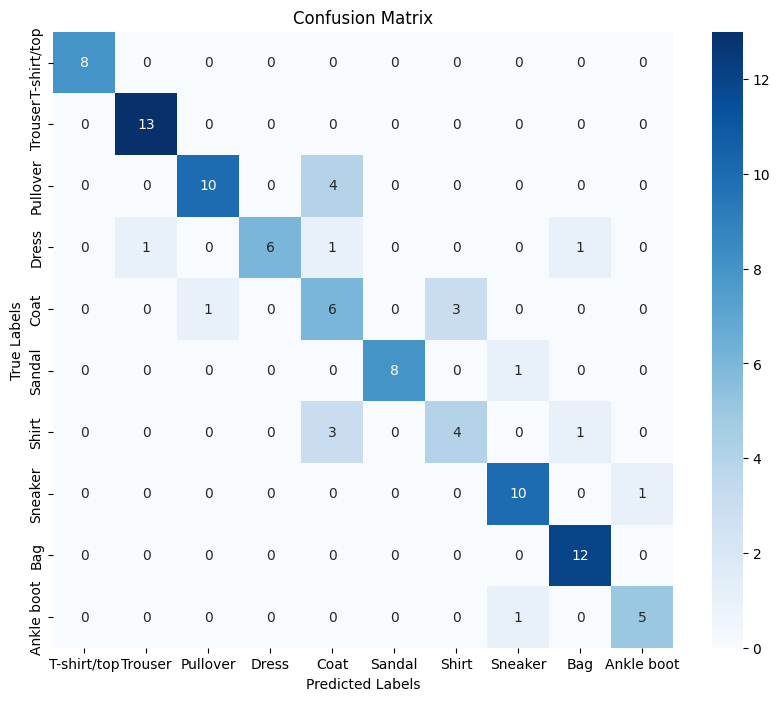

In [52]:
# Plot Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [53]:
# Save the Model
model.save('fashion_classifier_vgg16.h5')

In [63]:
from tensorflow.keras.models import load_model
# Load the saved model
model = load_model("fashion_classifier_vgg16.h5")
print("Model loaded successfully.")

# Define class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Prediction function for new image inputs
def predict_image(image):
    """
    Predicts the class label of a single image.

    Parameters:
        image (numpy array): Input image with shape (height, width) in grayscale.

    Returns:
        str: Predicted class label.
    """
    # Preprocess the input image
    image = tf.image.grayscale_to_rgb(tf.expand_dims(image, axis=-1))  # Convert grayscale to RGB
    image = tf.image.resize(image, (128, 128))  # Resize to model input size
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)  # Normalize the image
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    # Predict class label
    predictions = model.predict(image)
    predicted_class = class_names[np.argmax(predictions)]
    return predicted_class

Model loaded successfully.


In [67]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.5 MB/s eta 0:00:00


In [70]:
import keras_tuner as kt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define a model-building function for Keras Tuner
def build_model(hp):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    base_model.trainable = False  # Freeze the base model

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(hp.Int('units', min_value=64, max_value=256, step=64), activation='relu'),
        Dropout(hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-3, 1e-4])),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize the tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=5,
    factor=2,
    directory='hyperparam_tuning',
    project_name='fashion_mnist_mobilenetv2'
)

# Run the hyperparameter search
tuner.search(
    train_dataset,
    validation_data=test_dataset,
    epochs=5,
    verbose=1
)

# Retrieve the best hyperparameters and build the best model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)

# Train the best model
history = best_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5
)

Trial 20 Complete [00h 01m 16s]
val_accuracy: 0.75

Best val_accuracy So Far: 0.7599999904632568
Total elapsed time: 00h 20m 04s

Search: Running Trial #21

Value             |Best Value So Far |Hyperparameter
128               |256               |units
0.2               |0.4               |dropout
0.001             |0.001             |learning_rate
4                 |4                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
1                 |1                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 426ms/step - accuracy: 0.3930 - loss: 1.7680 - val_accuracy: 0.7000 - val_loss: 0.8381
Epoch 2/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 423ms/step - accuracy: 0.7419 - loss: 0.7471 - val_accuracy: 0.7500 - val_loss: 0.7268
Epoch 3/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 377ms/step - accuracy: 0.8116 - loss: 0.5944 - val_accuracy: 0.7600 - val_loss: 0.6865
Epoch 4/4


KeyboardInterrupt: 

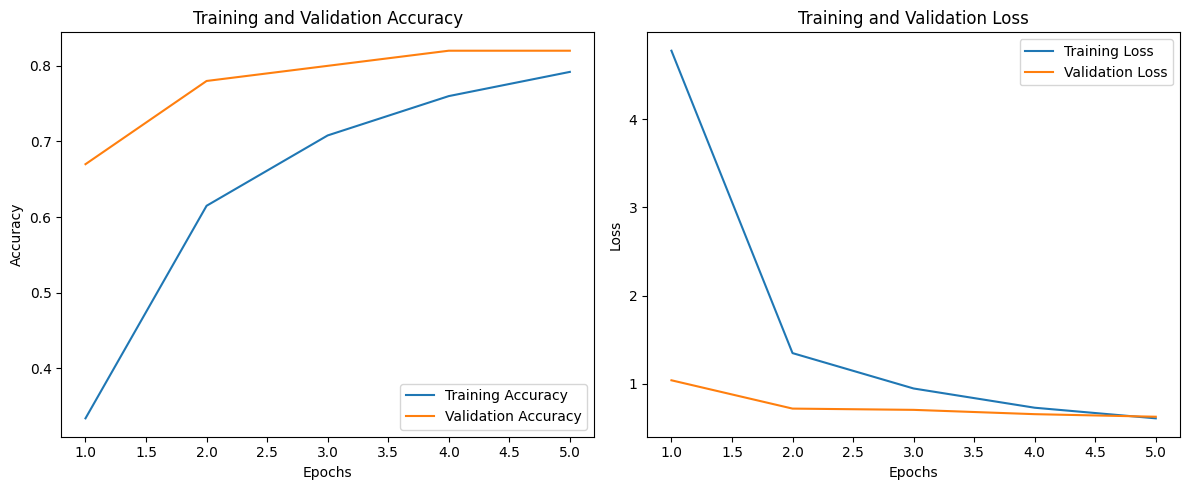

In [71]:
import matplotlib.pyplot as plt

# Function to Plot Training History
def plot_training_history(history):
    """
    Plots the training and validation accuracy and loss for a given training history.
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Plot Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call this function with your `history` object after model training
plot_training_history(history)
# Function for Prediction
def predict_image(image):
    image = tf.image.grayscale_to_rgb(tf.expand_dims(image, axis=-1))
    image = tf.image.resize(image, (128, 128)) # Change the resize dimensions to (128, 128)
    image = preprocess_input(image)
    image = np.expand_dims(image, axis=0)
    predictions = model.predict(image)
    return class_names[np.argmax(predictions)]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


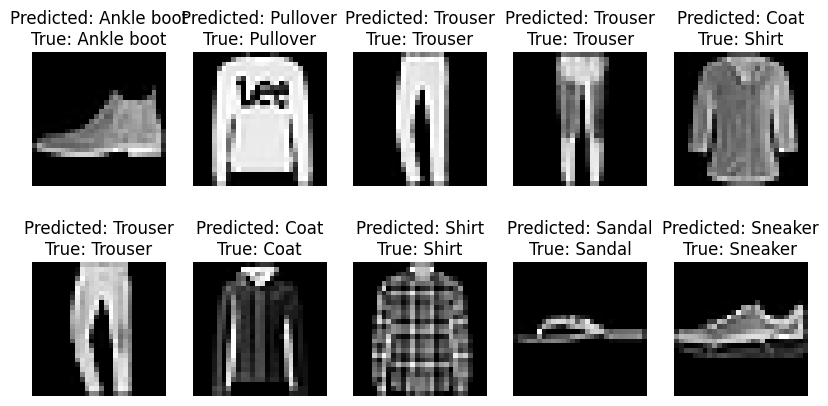

In [57]:
# Visualize Predictions
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Predicted: {predict_image(x_test[i])}\nTrue: {class_names[y_test[i]]}")
    plt.axis('off')
plt.show()